I'll explain decision trees from the ground up, building your understanding step by step.

## What is a Decision Tree?

A **decision tree** is a flowchart-like structure used for making decisions or predictions. It breaks down a complex decision into a series of simpler questions, much like playing "20 Questions."

Think of it like this: when a doctor diagnoses a patient, they don't randomly guess. They ask questions in sequence—"Do you have a fever?" "Does your throat hurt?"—and each answer leads them down a different path toward a diagnosis.

## Basic Structure

A decision tree has three types of nodes:

1. **Root Node**: The starting point, representing the entire dataset or the first question
2. **Internal Nodes**: Decision points where we ask questions and split the data
3. **Leaf Nodes**: End points that give us the final decision or prediction

## A Simple Example

Let's say we want to predict whether someone will play tennis based on weather conditions:

```
                    Outlook
                   /   |   \
              Sunny  Overcast  Rainy
               /        |        \
            Humid?     Play    Windy?
            /   \               /   \
        High   Normal      True   False
         /       \          /       \
      Don't    Play    Don't Play   Play
       Play              Play
```

## How Decision Trees Learn

The tree learns by finding the best questions to ask. But what makes a question "best"?

### The Goal: Purity

We want each split to create groups that are as **pure** as possible—meaning most items in each group belong to the same class. 

Imagine sorting a mixed bag of red and blue marbles. A perfect split would separate them so one side has only red marbles and the other only blue marbles.

### Key Concepts

**1. Entropy** (measuring impurity)

Entropy measures how mixed or uncertain a group is:
- Entropy = 0: perfectly pure (all same class)
- Entropy = 1: maximum impurity (50/50 split in binary classification)

Formula: `Entropy = -Σ(p_i × log₂(p_i))`

Where p_i is the proportion of class i.

**Example**: If we have 9 "Yes" and 5 "No":
- Entropy = -(9/14 × log₂(9/14)) - (5/14 × log₂(5/14)) ≈ 0.94

**2. Information Gain**

This measures how much a split reduces entropy. We calculate:
- Entropy before the split
- Weighted average entropy after the split
- Information Gain = Entropy(before) - Entropy(after)

We choose the split with the **highest information gain**.

**3. Gini Impurity** (alternative to entropy)

Another way to measure impurity: `Gini = 1 - Σ(p_i²)`

Used by the CART algorithm. It's computationally faster than entropy.

## The Algorithm (Step by Step)

1. **Start with all data** at the root node
2. **For each feature**, calculate what would happen if we split on it
3. **Choose the feature** that gives the best split (highest information gain or lowest Gini)
4. **Split the data** based on that feature
5. **Repeat recursively** for each branch until:
   - All data in a node is pure (same class)
   - No more features to split on
   - A stopping criterion is met (max depth, min samples, etc.)

## Types of Decision Trees

**Classification Trees**: Predict categories (yes/no, spam/not spam, cat/dog)
**Regression Trees**: Predict continuous values (house prices, temperature)

For regression, instead of majority class, leaf nodes contain the average value.

## Advantages

- Easy to understand and visualize
- Requires little data preparation
- Can handle both numerical and categorical data
- Can capture non-linear relationships
- Shows feature importance naturally

## Disadvantages

- Prone to **overfitting** (memorizing training data)
- Can be **unstable** (small data changes can drastically alter the tree)
- **Biased** toward features with more levels
- Can create overly complex trees

## Preventing Overfitting

**Pruning**: Cutting back the tree after it's grown
- Pre-pruning: Stop growing early (max depth, min samples per leaf)
- Post-pruning: Grow full tree, then remove branches that don't improve performance

**Other techniques**: 
- Set minimum samples for splits
- Limit maximum depth
- Use ensemble methods (Random Forests, Gradient Boosting)

## Real-World Applications

- Medical diagnosis
- Credit approval decisions
- Customer churn prediction
- Fraud detection
- Recommendation systems
- Image classification (as part of Random Forests)

## Popular Algorithms

- **ID3**: Uses entropy and information gain, handles categorical features
- **C4.5**: Improved ID3, handles continuous features and missing values
- **CART**: Uses Gini impurity, creates binary trees, used by scikit-learn

---

Would you like me to dive deeper into any particular aspect, like the mathematics, implementation in code, or a hands-on example with data?

### Decision Tree as Classifier

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# Load the Iris dataset
# Iris dataset has:
# - 150 samples
# - 4 features: sepal length, sepal width, petal length, petal width
# - 3 classes: 0 = Setosa, 1 = Versicolor, 2 = Virginica
iris = load_iris()

# Select only the last two features: petal length and petal width
# These two features are highly discriminative for separating the species
X = iris.data[:, 2:]  # shape: (150, 2)

# Target labels: 0, 1, 2
y = iris.target  # shape: (150,)

# Create a decision tree classifier
# max_depth=2 limits the tree to 2 levels
# This prevents overfitting and allows a simple interpretable model
tree_clf = DecisionTreeClassifier(max_depth=2)

# Fit the decision tree to the data
# The tree learns to split the data based on petal length and width
# It chooses splits that maximize information gain (or equivalently minimize Gini impurity by default)
tree_clf.fit(X, y)


,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
from sklearn.tree import export_graphviz

# Export the trained decision tree to a DOT file (Graphviz format)
# This allows visualization of the tree using Graphviz tools or online viewers
export_graphviz(
    tree_clf,                       # The trained DecisionTreeClassifier object
    out_file="iris_tree.dot",  # Path to save the .dot file
                                           # You can later convert it to PNG, PDF, etc.
    feature_names=iris.feature_names[2:],  # Names of features used in the tree
                                           # Here: ['petal length (cm)', 'petal width (cm)']
    class_names=iris.target_names,         # Names of the target classes
                                           # ['setosa', 'versicolor', 'virginica']
    rounded=True,                          # Draw rounded boxes for tree nodes
    filled=True                            # Fill nodes with colors representing classes
)


In [ ]:
import graphviz

# Read the DOT file
with open("iris_tree.dot") as f:
    dot_graph = f.read()

# Render and display the tree
graphviz.Source(dot_graph)

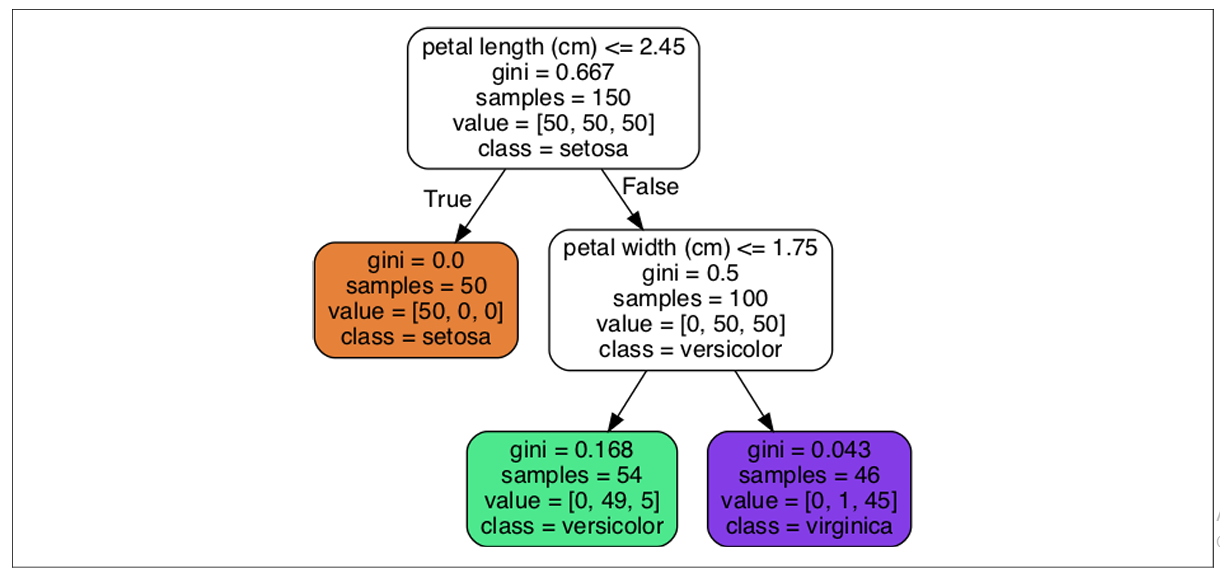

In [9]:
tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [10]:
tree_clf.predict([[5, 1.5]])

array([1])

### Decision Tree as Regressor

In [11]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(max_depth=2)
tree_reg.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


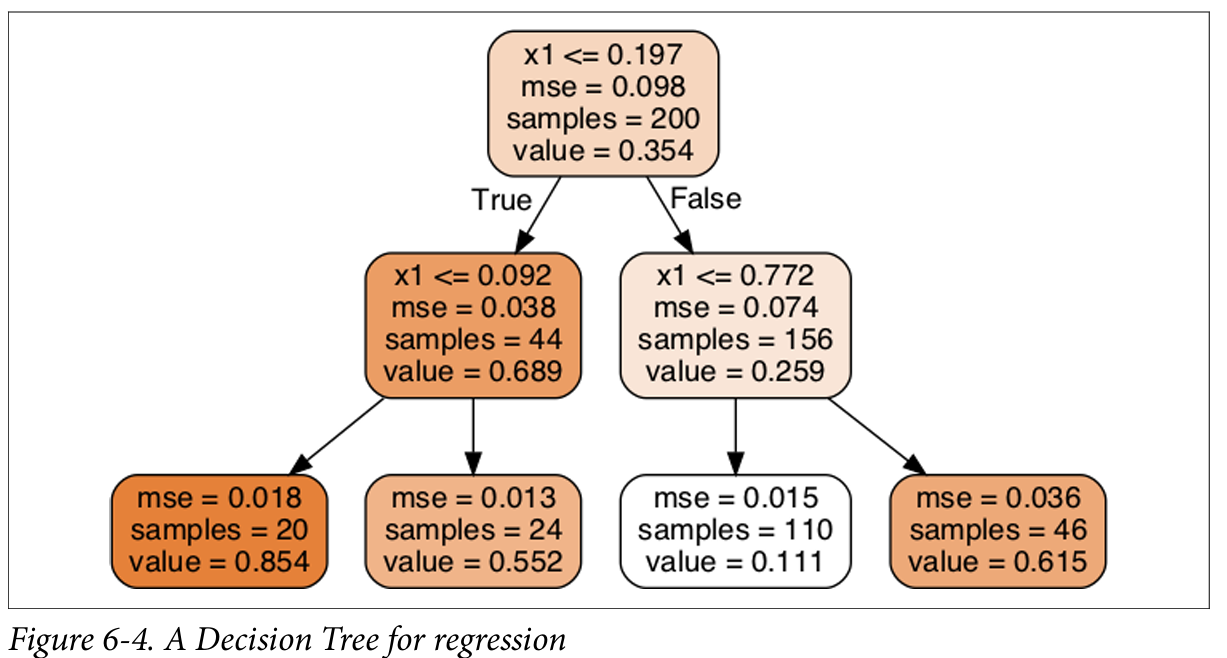